In [2]:
pip install pyforest

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for pyforest: filename=pyforest-1.1.2-py2.py3-none-any.whl size=15927 sha256=d068a09e8c8c46dce333824f93dab42181ffdc12adf465854fa7bf9f34c5e6da
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\75\a0\a6\9bcd20ada25fc166bdc9d2d1f69abf5b1bd40ef1718b112a19
Successfully built pyforest
Note: you may need to restart the kernel to use updated packages.


In [3]:
df=pd.read_csv("Medicaldataset.csv")
df.head()

<IPython.core.display.Javascript object>

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,63,1,66,160,83,160.0,1.80,0.012,negative
1,20,1,94,98,46,296.0,6.75,1.060,positive
2,56,1,64,160,77,270.0,1.99,0.003,negative
3,66,1,70,120,55,270.0,13.87,0.122,positive
4,54,1,64,112,65,300.0,1.08,0.003,negative


In [4]:
df.tail()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive
1318,51,1,94,157,79,134.0,50.89,1.770,positive


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [6]:
df.dtypes

Age                           int64
Gender                        int64
Heart rate                    int64
Systolic blood pressure       int64
Diastolic blood pressure      int64
Blood sugar                 float64
CK-MB                       float64
Troponin                    float64
Result                       object
dtype: object

In [29]:
df.isna().sum()

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

In [30]:
df.duplicated().sum()

0

In [11]:
df.groupby('Gender').agg(result=('Age','mean'))

,result
Gender,
0,57.968820
1,55.277011


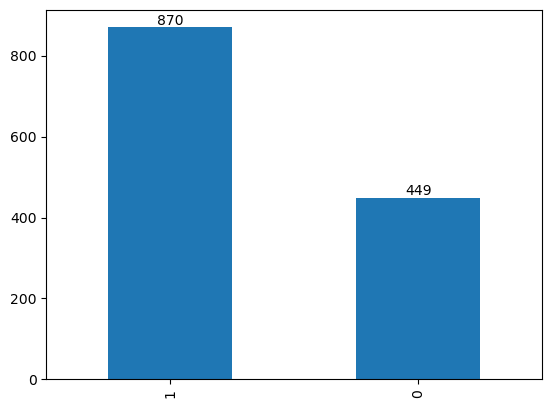

In [18]:
ax=df['Gender'].value_counts().plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)

<IPython.core.display.Javascript object>

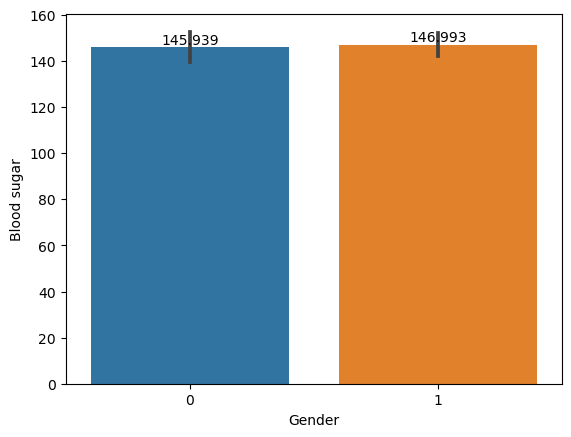

In [22]:
ax=sns.barplot(df,x='Gender',y='Blood sugar')
for i in ax.containers:
    ax.bar_label(i)

<IPython.core.display.Javascript object>

<Axes: xlabel='Blood sugar', ylabel='Count'>

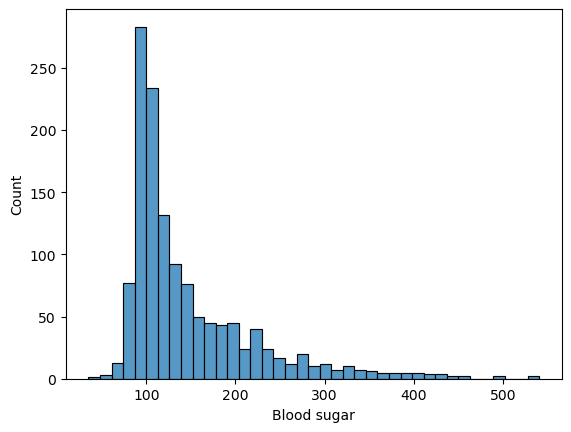

In [28]:
sns.histplot(data=df,x='Blood sugar')

In [31]:
from sklearn.preprocessing import OrdinalEncoder
encoded=OrdinalEncoder()
df[['Result']]=encoded.fit_transform(df[['Result']])
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,63,1,66,160,83,160.0,1.80,0.012,0.0
1,20,1,94,98,46,296.0,6.75,1.060,1.0
2,56,1,64,160,77,270.0,1.99,0.003,0.0
3,66,1,70,120,55,270.0,13.87,0.122,1.0
4,54,1,64,112,65,300.0,1.08,0.003,0.0


In [34]:
from sklearn.preprocessing import StandardScaler
scaled=StandardScaler()
df[['Blood sugar']]=scaled.fit_transform(df[['Blood sugar']])
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,63,1,66,160,83,0.178459,1.80,0.012,0.0
1,20,1,94,98,46,1.994344,6.75,1.060,1.0
2,56,1,64,160,77,1.647189,1.99,0.003,0.0
3,66,1,70,120,55,1.647189,13.87,0.122,1.0
4,54,1,64,112,65,2.047752,1.08,0.003,0.0


In [63]:
x=df.drop(columns=('Result'))
y=df['Result']

In [67]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,
                                              test_size=0.2,random_state=45)



In [77]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [78]:
y_predict=dtc.predict(x_test)
y_predict

array([1., 1., 1., 0., 1., 1., 1., 0., 0., 1., 1., 0., 1., 1., 0., 1., 0.,
       1., 1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0.,
       1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 0.,
       1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0.,
       1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1., 1., 0., 0., 0.,
       0., 1., 0., 1., 1., 0., 0., 0., 0., 1., 1., 1., 0., 0., 1., 1., 1.,
       1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0., 1.,
       0., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 1., 1., 1.,
       1., 0., 1., 0., 1.

In [82]:
from sklearn.metrics import accuracy_score

In [79]:
accuracy_score(y_test,y_predict)

0.9848484848484849